# Import data

In [1]:
# import zipfile

# zip_file = zipfile.ZipFile("OriginalDataset.zip",'r')
# zip_file.extractall()

In [2]:
import cv2
import matplotlib.pyplot as plt

def imshow(filename):
  image = cv2.imread(filename)

  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()
  print(image.shape)

In [3]:
path = 'D:/programing/Final Project/Alzheimer/dataset/Dataset/'

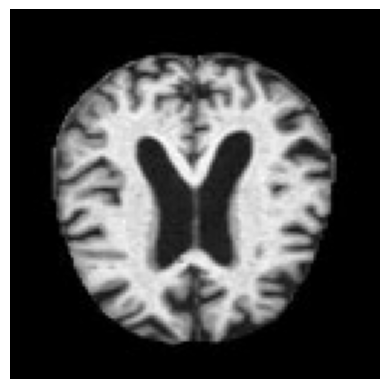

(128, 128, 3)


In [4]:
imshow(path+'Mild_Demented/mild.jpg')

# Image Preprocessing

In [5]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
import numpy as np
import random
random.seed(0)
torch.manual_seed(0)
np.random.seed(0)
torchvision.disable_beta_transforms_warning()

## CustomDataset to import dataset

In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.images = self._get_images()
        self.class_count = self._get_class_count()

    def _get_images(self):
        images = []
        for cls in self.classes:
            class_path = os.path.join(self.root_dir, cls)
            class_idx = self.class_to_idx[cls]
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                images.append((img_path, class_idx))
        return images
    
    def _get_class_count(self):
        class_count = {}
        for cls_name in self.class_to_idx.values():
            class_count[cls_name] = 0
        for key,value in self.images:
           class_count[value] += 1 
        return class_count
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)
        return img, label
    
    def get_labels(self):
        return [i[1] for i in self.images]

## AddGaussianNoise

In [7]:
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=1.0, probability=0.5):
        self.std = std
        self.mean = mean
        self.probability = probability
        
    def __call__(self, tensor):
        if random.random() < self.probability:
            return tensor + (torch.randn(tensor.size()) * self.std) + self.mean
        else:
            return tensor
    
    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

## Contrast-limited Adaptive Histogram Equalization (CLAHE)

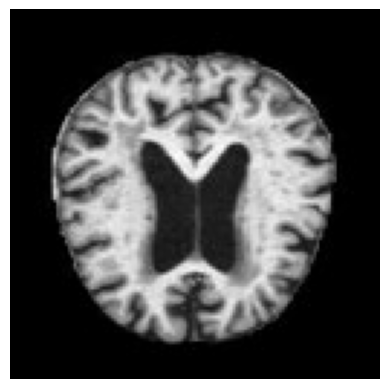

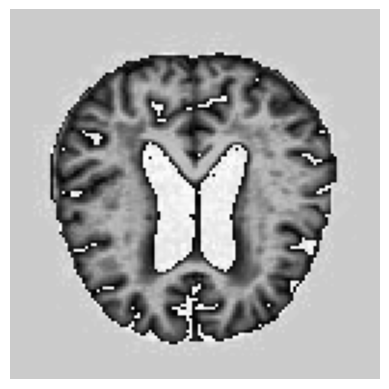

In [8]:
# Reading the image from the present directory
image = cv2.imread(path+'Mild_Demented/mild_2.jpg')
# Resizing the image for compatibility

# The initial processing of the image
# image = cv2.medianBlur(image, 3)
image_bw = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
 
# The declaration of CLAHE
# clipLimit -> Threshold for contrast limiting
clahe = cv2.createCLAHE(clipLimit=3,tileGridSize=(1,1))
final_img = clahe.apply(image_bw) + 200
 
# Showing the two images
plt.imshow(cv2.cvtColor(image_bw, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [9]:
import cv2

class AddCLAHE():
    def __init__(self, clipLimit=3, tileGridSize=(1, 1), threshold=200) -> None:
        self.clipLimit = clipLimit
        self.tileGridSize = tileGridSize
        self.threshold = threshold

    def __call__(self, tensor):
        tensor = tensor.numpy() * 255 
        tensor = tensor.astype('uint8')[0]

        clahe = cv2.createCLAHE(clipLimit=self.clipLimit, tileGridSize=self.tileGridSize)
        transformed_tensor = clahe.apply(tensor)
        transformed_tensor = torch.from_numpy(transformed_tensor).float() + self.threshold
        transformed_tensor = transformed_tensor / 255
        transformed_tensor = transformed_tensor.unsqueeze(0)

        return transformed_tensor

    def __repr__(self):
        return self.__class__.__name__ + '(clipLimit={}, tileGridSize={}, threshold={})'.format(
            self.clipLimit, self.tileGridSize, self.threshold
        )

## Split white and gray matter

In [10]:
class split_white_and_gray():
    def __init__(self,threshold=120) -> None:
        self.threshold = threshold

    def __call__(self,tensor):
        tensor = (tensor*255).to(torch.int64)

        # Apply thresholding
        gray_matter = torch.where(tensor >= self.threshold,tensor,0)
        gray_matter = (gray_matter/255).to(torch.float64)
        white_matter = torch.where(tensor < self.threshold,tensor,0)
        white_matter = (white_matter/255).to(torch.float64)

        return torch.cat((gray_matter, white_matter), dim=0)

## Apply transforms

In [11]:
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    split_white_and_gray(120),
    #AddCLAHE(),
    #AddGaussianNoise(0,0.05), 
])

In [12]:
Dataset = CustomDataset(root_dir='D:/programing/Final Project/Alzheimer/dataset/Dataset', transform=transform)

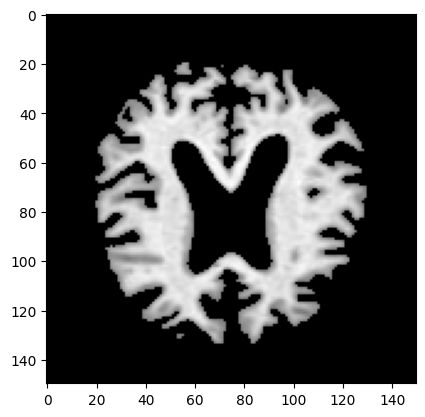

In [13]:
plt.imshow(transforms.ToPILImage()(Dataset[0][0][0]),cmap='gray')
plt.show()

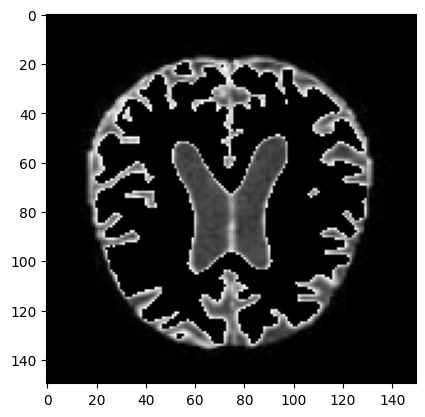

In [14]:
plt.imshow(transforms.ToPILImage()(Dataset[0][0][1]),cmap='gray')
plt.show()

## Over sampling method

In [15]:
# Calculate class weights for oversampling
class_counts = list(Dataset._get_class_count().values())
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)

# Assign weights to each sample based on its class
weights = [class_weights[label] for _, label in Dataset.images]

# Create a WeightedRandomSampler to oversample minority classes
sampler = WeightedRandomSampler(weights, 20000, replacement=True)

# Create a DataLoader with the WeightedRandomSampler
dataloader = DataLoader(Dataset, batch_size=64,sampler=sampler)

In [16]:
class_counts = {label: 0 for label in range(len(Dataset.classes))}

# Iterate through the DataLoader
for _, labels in dataloader:
    for label in labels:
        class_counts[label.item()] += 1

# Print the counts
for label, count in class_counts.items():
    print(f"Class {label}: {count} items")

Class 0: 4937 items
Class 1: 4932 items
Class 2: 5087 items
Class 3: 5044 items


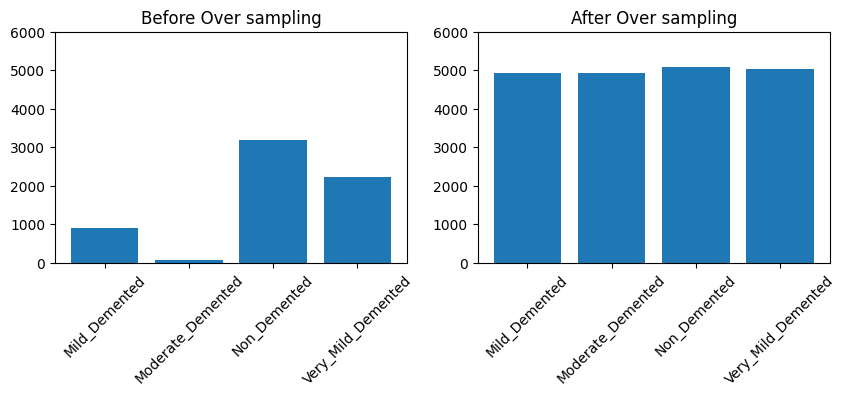

In [17]:
# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))  # Adjust the figsize as needed

# Add the first subplot
ax1.bar(Dataset.classes, Dataset.class_count.values())
ax1.set_xticks(range(len(Dataset.classes)))
ax1.set_xticklabels(Dataset.classes, rotation=45)
ax1.set_ylim(top=6000)
ax1.set_title("Before Over sampling")

# Add the second subplot
ax2.bar(Dataset.classes, class_counts.values())
ax2.set_xticks(range(len(Dataset.classes)))
ax2.set_xticklabels(Dataset.classes, rotation=45)
ax2.set_ylim(top=6000)
ax2.set_title("After Over sampling")

plt.show()


## visualization of each class

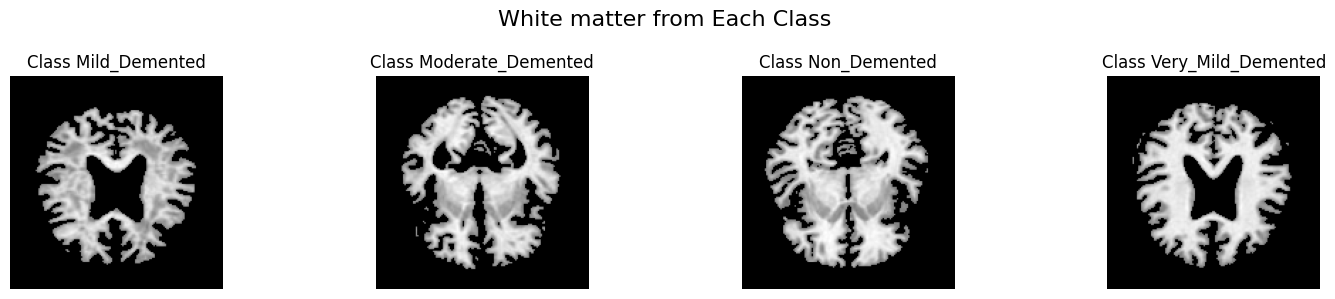

In [18]:
images, labels = next(iter(dataloader))

img_index = []
for label in labels.unique():
    img_index.append(list(labels).index(label))

image_each_classes = []
for idx in img_index:
    image_each_classes.append(images[idx])

# Plot one image from each class
fig, axs = plt.subplots(1, len(Dataset.classes), figsize=(15, 3))
fig.suptitle("White matter from Each Class", fontsize=16)

for class_num, i in enumerate(zip(Dataset.classes,image_each_classes)):
    axs[class_num].imshow(transforms.ToPILImage()(i[-1][0]),cmap='gray')
    axs[class_num].set_title(f"Class {i[0]}")
    axs[class_num].axis('off')

plt.tight_layout()
plt.show()

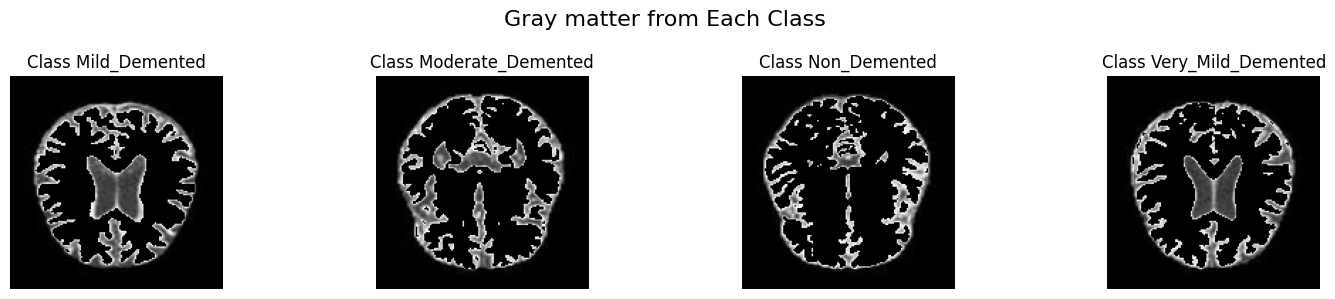

In [19]:
# Plot one image from each class
fig, axs = plt.subplots(1, len(Dataset.classes), figsize=(15, 3))
fig.suptitle("Gray matter from Each Class", fontsize=16)

for class_num, i in enumerate(zip(Dataset.classes,image_each_classes)):
    axs[class_num].imshow(transforms.ToPILImage()(i[-1][1]),cmap='gray')
    axs[class_num].set_title(f"Class {i[0]}")
    axs[class_num].axis('off')

plt.tight_layout()
plt.show()